In [1]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import colorspacious

In [2]:
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r"\usepackage{libertine}\usepackage{sansmath}\sansmath")
params = {"axes.labelsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9}
plt.rcParams.update(params)

In [3]:
def gamut_slice(J, colors=[], min_delta_E=20, res=75):
    jab = np.stack(
        [np.ones((res, res)) * J]
        + np.meshgrid(np.linspace(-33, 43, res), np.linspace(-40, 36, res)),
        axis=2,
    )
    rgb = colorspacious.cspace_convert(jab, "CAM02-UCS", "sRGB1")
    # Clip out of gamut
    rgb[np.logical_or(np.min(rgb, axis=2) < 0, np.max(rgb, axis=2) > 1)] = 1
    # Clip colors that are too close
    for i, c in enumerate(colors):
        fill = 1 if i < len(colors) - 1 else 0.85
        rgb[colorspacious.deltaE(rgb, c) < min_delta_E] = fill
        for t in ["deuteranomaly", "protanomaly", "tritanomaly"]:
            for severity in range(1, 101):
                cvd_space = {"name": "sRGB1+CVD", "cvd_type": t, "severity": severity}
                rgb[
                    colorspacious.deltaE(
                        colorspacious.cspace_convert(rgb, cvd_space, "sRGB1"),
                        colorspacious.cspace_convert(c, cvd_space, "sRGB1"),
                    )
                    < min_delta_E
                ] = fill
    return rgb

In [4]:
with open("../set-generation/colors_mcd20.0_mld5.0_nc6_cvd100_minj40_maxj80_ns10000_f.txt") as csv_file:
    # Skip header rows
    csv_file.readline()
    csv_file.readline()
    csv_file.readline()
    csv_reader = csv.reader(csv_file, delimiter=" ")
    colors_rgb = []
    for row in csv_reader:
        row = [i.strip() for i in row]
        rgb = [(int(i[:2], 16), int(i[2:4], 16), int(i[4:], 16)) for i in row]
        colors_rgb.append(rgb)
colors_rgb = np.array(colors_rgb) / 255

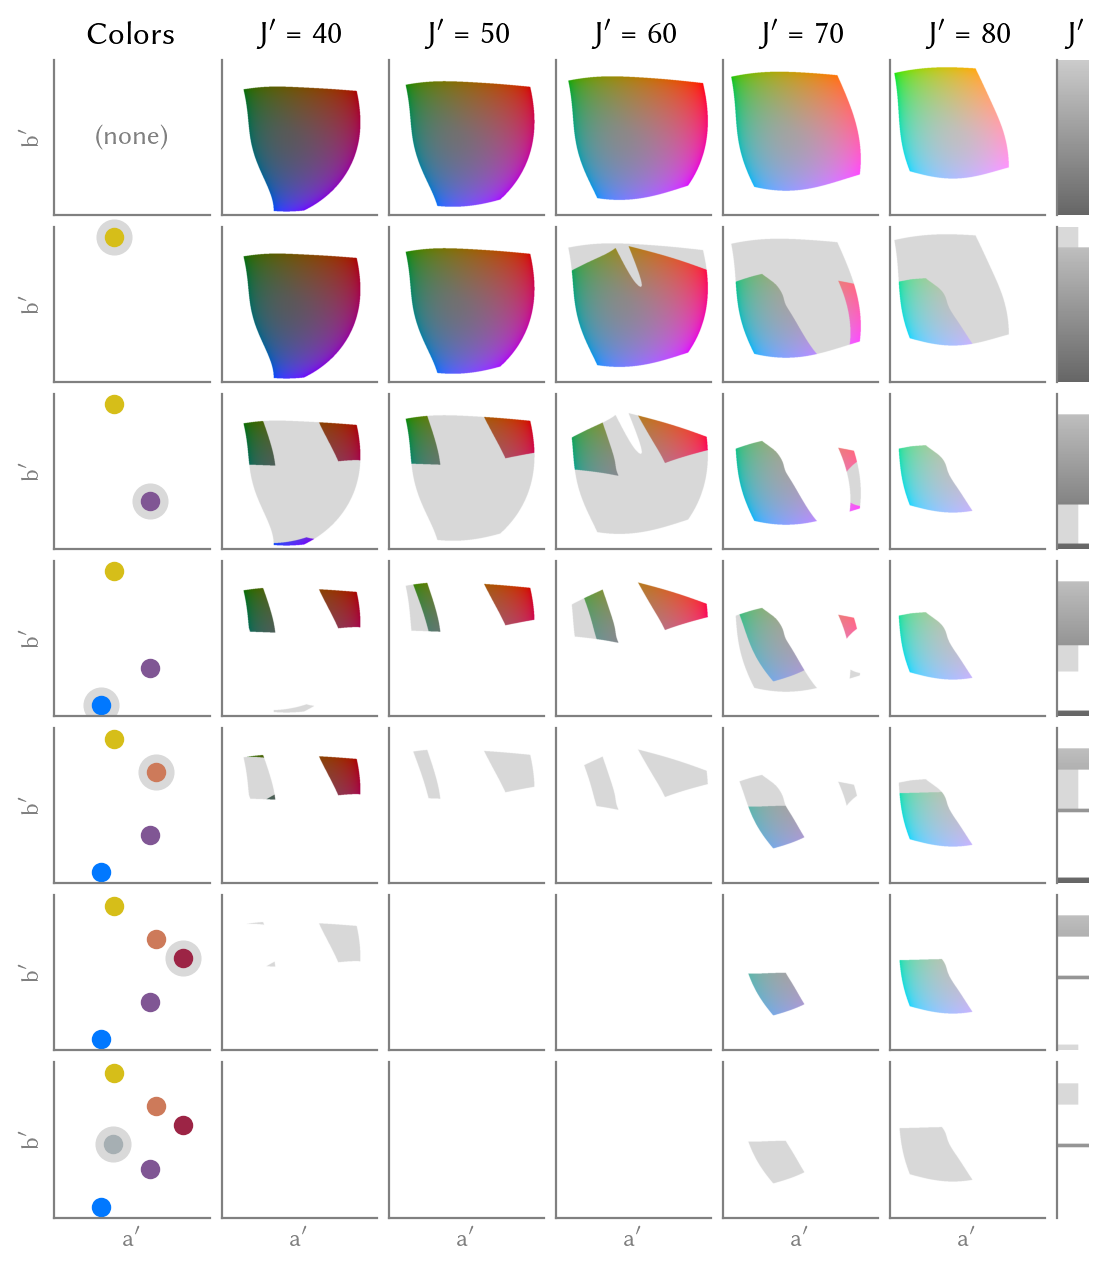

In [5]:
res = 600
min_delta_J = 5
colors = colors_rgb[45][[5, 1, 0, 4, 2, 3]]

fig, ax = plt.subplots(
    1 + colors.shape[0],
    7,
    layout="compressed",
    width_ratios=[1] * 6 + [0.2],
    figsize=(5.4, 6.3),
)
fig.get_layout_engine().set(
    w_pad=0.03, h_pad=0.03, hspace=0, wspace=0
)  # Reduce padding
ax_color = "0.5"  # To make axes less prominent
for i in range(1 + colors.shape[0]):
    # Plot colors in first column
    for k, c in enumerate(colors[:i]):
        ab = colorspacious.cspace_convert(c, "sRGB1", "CAM02-UCS")[1:]
        if k == i - 1:
            # Outline in light gray if last color
            scat = ax[i, 0].scatter(
                *ab,
                c="0.85",
                s=(2 * plt.rcParams["lines.markersize"]) ** 2,
                zorder=-1,
            )
            if max(ab) > 25:
                # Don't clip marker edge on edges of plot without frame
                scat.set_clip_on(False)
        scat = ax[i, 0].scatter(*ab, c=[c])
        if max(ab) > 25:
            # Don't clip marker edge on edges of plot without frame
            scat.set_clip_on(False)
    # Plot gamut slices
    for j in range(5):
        ax[i, j + 1].imshow(
            gamut_slice(40 + j * 10, colors=colors[:i], res=res),
            origin="lower",
            extent=(-33, 43, -40, 36),
            aspect="equal",
        )
        if i == 0:
            # Set titles for top row
            ax[i, j + 1].set_title(f"J$' = {40 + j * 10}$")
    # Formatting
    ax[i, 0].set_ylabel("b$'$", c=ax_color)
    ax[i, 0].set_aspect("equal")
    for j in range(7):
        ax[i, j].spines["right"].set_visible(False)
        ax[i, j].spines["top"].set_visible(False)
        ax[i, j].spines["left"].set_color(ax_color)
        ax[i, j].spines["bottom"].set_color(ax_color)
        ax[i, j].set_xticks([])
        ax[i, j].set_yticks([])
        if i == colors.shape[0] and j < 6:
            ax[i, j].set_xlabel("a$'$", c=ax_color)
    # Match axes of first column to gamut slice panels
    # We don't share the axes, since the last column is different
    ax[i, 0].set_xlim(ax[i, 1].get_xlim())
    ax[i, 0].set_ylim(ax[i, 1].get_ylim())
    # Plot available J' range
    gray = np.linspace(40, 80, res)
    gray = np.stack([gray] * (gray.size // 5), axis=-1)
    for k, c in enumerate(colors[:i]):
        j = colorspacious.cspace_convert(c, "sRGB1", "CAM02-UCS")[0]
        if k < i - 1:
            gray[np.abs(j - gray) < min_delta_J] = 100
        else:
            for col in range(gray.shape[1]):
                # Use a different width to show removed J range
                fill = 100 if col > gray.shape[1] - gray.shape[1] // 3 - 1 else 85
                gray[:, col][np.abs(j - gray[:, col]) < min_delta_J] = fill
    ax[i, 6].imshow(gray, origin="lower", cmap="gray", vmin=0, vmax=100)
    ax[i, 6].spines["bottom"].set_visible(False)
ax[0, 0].set_title("Colors")
ax[0, 0].text(
    0.5,
    0.5,
    "(none)",
    ha="center",
    va="center",
    transform=ax[0, 0].transAxes,
    c=ax_color,
)
ax[0, 6].set_title("J$'$")
fig.savefig("set-generation.pdf", dpi=300)